# FraudGuard — Final Rapor
## Kredi Kartı Dolandırıcılığı Tespiti

**Ders:** Makine Öğrenmesi  
**Tarih:** 2026-05-07  
**Dataset:** Kaggle — mlg-ulb/creditcardfraud

---

## 1. Problem Tanımı

Avrupa bankalarına ait kredi kartı işlemlerinde dolandırıcılık tespiti.  
Dataset **284,807 işlem** içermekte olup yalnızca **492'si (%0.17) fraud**'dur.  
Bu aşırı dengesizlik, doğru metrik seçimini ve imbalance stratejisini kritik kılmaktadır.

**Birincil metrik:** PR-AUC ve F1 (Accuracy yanıltıcı olduğundan kullanılmamıştır)

---

## 2. Metodoloji

| Adım | Yöntem | Not |
|------|--------|-----|
| Split | 80/20 stratified, random_state=42 | EDA'dan önce yapıldı |
| Scaling | StandardScaler — sadece train'de fit | Test sızıntısı önlendi |
| Imbalance | class_weight / scale_pos_weight | SMOTE train-only uygulanabilir |
| Modeller | LR → RF → XGBoost → Isolation Forest | 4 farklı yaklaşım |
| Threshold | F1-optimal (0.9457) + Maliyet-optimal (0.4581) | İki perspektif |
| Cost | FN=$100, FP=$10 varsayımı | Akademik basitleştirme |

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

METRICS_DIR = Path('../results/metrics')
FIGURES_DIR = Path('../results/figures')

def load_json(path):
    with open(path) as f:
        return json.load(f)

## 3. Final Model Karşılaştırması

In [2]:
final = load_json(METRICS_DIR / '10_final_comparison.json')
cost  = load_json(METRICS_DIR / '11_business_cost_metrics.json')

df = pd.DataFrame(final['models']).set_index('model')
print('=== Tüm Modeller — Test Seti Metrikleri ===')
print(df[['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'FP', 'FN']].to_string())

print('\n=== En İyi Değer — Her Metrik İçin ===')
for metric, info in final['best_per_metric'].items():
    print(f'  {metric:10s}: {info["value"]:.4f}  →  {info["model"]}')

print('\n=== Business Cost Analizi ===')
print(f'  Naive baseline maliyeti : ${cost["naive_baseline_cost"]:,}')
for s in cost['scenarios']:
    print(f'  {s["name"]}: ${s["total_cost_usd"]:,}  (FP={s["FP"]}, FN={s["FN"]})')

=== Tüm Modeller — Test Seti Metrikleri ===
                                 Precision  Recall      F1  ROC-AUC  PR-AUC  FP  FN
model                                                                              
Logistic Regression (0.50)          0.8267  0.6327  0.7168   0.9605  0.7414  13  36
Random Forest (0.50)                0.9605  0.7449  0.8391   0.9529  0.8539   3  25
XGBoost (0.50)                      0.7757  0.8469  0.8098   0.9815  0.8597  24  15
XGBoost (optimal 0.9457)            0.9195  0.8163  0.8649   0.9815  0.8597   7  18
Isolation Forest (unsupervised)     0.3084  0.3367  0.3220   0.9543  0.2180  74  65

=== En İyi Değer — Her Metrik İçin ===
  Precision : 0.9605  →  Random Forest (0.50)
  Recall    : 0.8469  →  XGBoost (0.50)
  F1        : 0.8649  →  XGBoost (optimal 0.9457)
  ROC-AUC   : 0.9815  →  XGBoost (0.50)
  PR-AUC    : 0.8597  →  XGBoost (0.50)

=== Business Cost Analizi ===
  Naive baseline maliyeti : $9,800
  Varsayılan (0.5000): $1,740  (FP=24, FN=15)


## 4. Ana Görseller

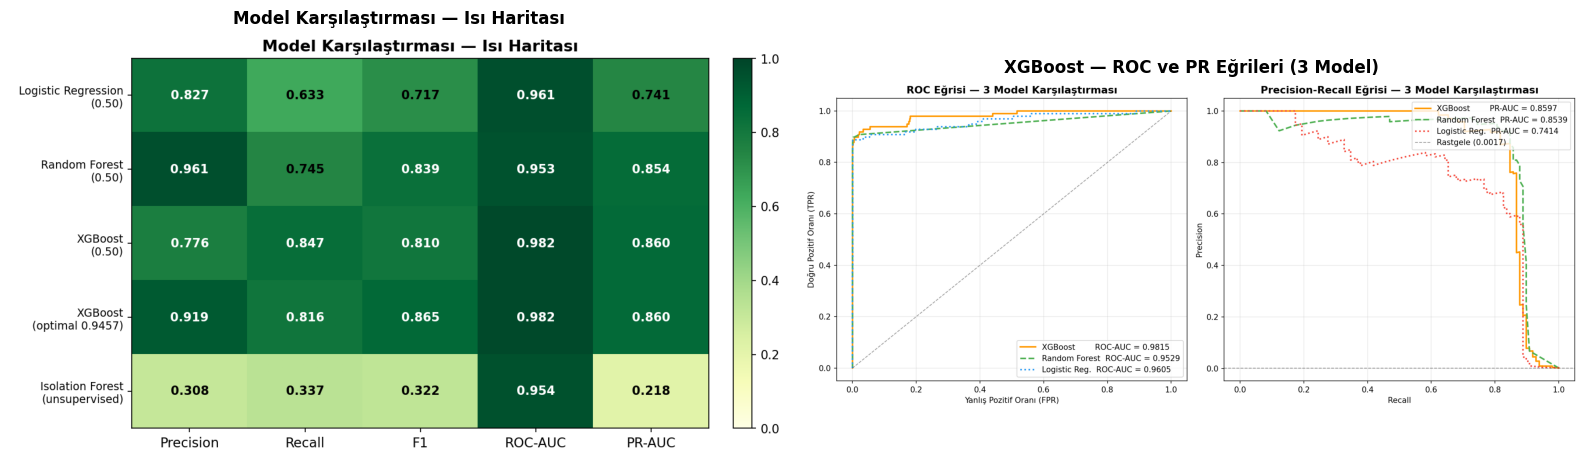

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

img1 = mpimg.imread(FIGURES_DIR / '20_model_comparison_heatmap.png')
img2 = mpimg.imread(FIGURES_DIR / '13_xgb_roc_pr_curves.png')

axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('Model Karşılaştırması — Isı Haritası', fontsize=12, fontweight='bold')

axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('XGBoost — ROC ve PR Eğrileri (3 Model)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

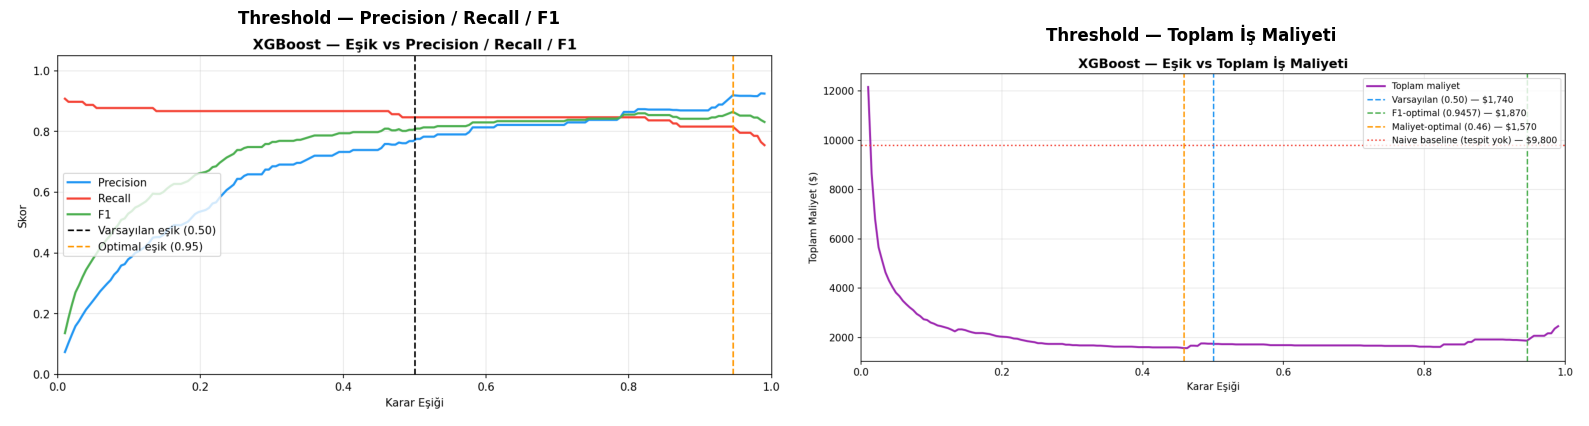

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img3 = mpimg.imread(FIGURES_DIR / '17_threshold_metrics_curve.png')
img4 = mpimg.imread(FIGURES_DIR / '21_cost_vs_threshold.png')

axes[0].imshow(img3)
axes[0].axis('off')
axes[0].set_title('Threshold — Precision / Recall / F1', fontsize=12, fontweight='bold')

axes[1].imshow(img4)
axes[1].axis('off')
axes[1].set_title('Threshold — Toplam İş Maliyeti', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Bulgular ve Yorumlar

### 5.1 Model Performansı

| Bulgu | Detay |
|-------|-------|
| **En yüksek ROC-AUC ve PR-AUC** | XGBoost (0.9815 / 0.8597) |
| **En yüksek Precision** | Random Forest (0.9605) — en az yanlış alarm |
| **En yüksek Recall** | XGBoost varsayılan (0.8469) — en az kaçırılan fraud |
| **Isolation Forest** | ROC-AUC 0.9543 — etiket olmadan güçlü sıralama |

### 5.2 Eşik Seçimi

| Perspektif | Eşik | F1 | Maliyet |
|------------|------|----|---------|
| Varsayılan | 0.50 | 0.8098 | $1,740 |
| F1-Optimal | 0.9457 | **0.8649** | $1,870 |
| **Maliyet-Optimal** | **0.4581** | 0.8095 | **$1,570** |

F1-optimal eşik daha iyi F1 üretir; ancak FN maliyeti ağır olduğundan toplam maliyet **daha yüksektir**.
Maliyet-optimal eşik (≈0.46) fraud'u agresif yakalar (Recall=0.87), FP artışı kabul edilebilir seviydedir.

## 6. Sonuç ve Öneri

**Önerilen model:** XGBoost  
**Önerilen eşik:** İş senaryosuna göre:
- Minimum yanlış alarm → `0.9457` (precision odaklı)
- Minimum iş maliyeti → `0.4581` (cost odaklı)
- Maksimum fraud yakalama → `0.50` (recall odaklı)

## 7. Sınırlamalar

- V1–V28 özellikleri anonimleştirilmiş (PCA); domain yorumu kısıtlı
- İş maliyet varsayımları gerçek banka verileriyle doğrulanmamış
- Zaman boyutu (Time) modelde kullanılmadı; temporal split denenebilir
- RobustScaler alternatifi henüz test edilmedi (Amount aykırı değerleri mevcut)

## 8. Gelecek Çalışmalar

- Hyperparameter optimizasyonu (Optuna / GridSearchCV)
- SHAP değerleriyle model yorumlanabilirliği
- Gerçek zamanlı tahmin API'si
- Temporal cross-validation ile daha sağlam değerlendirme